In [45]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


EDA

In [46]:
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\practice\RandomForest-CaseStudy (3).csv')
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [47]:
df.shape

(10129, 19)

In [48]:
df.columns

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [50]:
df1=df.drop(['Date','Time'],axis=1)
df1.head()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [51]:
temp_col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].endswith('Temp')]
temp_col

['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']

In [52]:
for i in range(len(temp_col)):
    df1.rename(columns={temp_col[i]: 'Temp_'+str(i+1)}, inplace=True)


In [53]:
light_col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].endswith('Light')]
light_col

['S1_Light', 'S2_Light', 'S3_Light', 'S4_Light']

In [54]:
for i in range(len(light_col)):
    df1.rename(columns={light_col[i]: 'Light_'+str(i+1)}, inplace=True)


In [56]:
sound_col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].endswith('Sound')]
sound_col

['S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound']

In [57]:
for i in range(len(sound_col)):
    df1.rename(columns={sound_col[i]: 'Sound_'+str(i+1)}, inplace=True)


In [58]:
co2_col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].startswith('S5')]
co2_col

['S5_CO2', 'S5_CO2_Slope']

In [59]:
pir_col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].endswith('PIR')]
pir_col

['S6_PIR', 'S7_PIR']

In [60]:
df1.head

<bound method NDFrame.head of        Temp_1  Temp_2  Temp_3  Temp_4  Light_1  Light_2  Light_3  Light_4  \
0       24.94   24.75   24.56   25.38      121       34       53       40   
1       24.94   24.75   24.56   25.44      121       33       53       40   
2       25.00   24.75   24.50   25.44      121       34       53       40   
3       25.00   24.75   24.56   25.44      121       34       53       40   
4       25.00   24.75   24.56   25.44      121       34       54       40   
...       ...     ...     ...     ...      ...      ...      ...      ...   
10124   25.06   25.13   24.69   25.31        6        7       33       22   
10125   25.06   25.06   24.69   25.25        6        7       34       22   
10126   25.13   25.06   24.69   25.25        6        7       34       22   
10127   25.13   25.06   24.69   25.25        6        7       34       22   
10128   25.13   25.06   24.69   25.25        6        7       34       22   

       Sound_1  Sound_2  Sound_3  Sound_4  S5

In [61]:
df1.describe()

,Temp_1,Temp_2,Temp_3,Temp_4,Light_1,Light_2,Light_3,Light_4,Sound_1,Sound_2,Sound_3,Sound_4,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


DATA PREPROCESSING

In [62]:
df1.isnull().sum()

Temp_1                  0
Temp_2                  0
Temp_3                  0
Temp_4                  0
Light_1                 0
Light_2                 0
Light_3                 0
Light_4                 0
Sound_1                 0
Sound_2                 0
Sound_3                 0
Sound_4                 0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64

In [63]:
df1.duplicated().sum()

np.int64(1301)

In [64]:
df1=df1.drop_duplicates()


In [65]:
df1.duplicated().sum()

np.int64(0)

In [66]:
df1.shape

(8828, 17)

DATA VISUALISIATION

The class distribution graph shows that the dataset is imbalanced, with the majority of records belonging to the unoccupied class (0). This indicates that the room remains empty most of the time.

<Axes: xlabel='Room_Occupancy_Count', ylabel='count'>

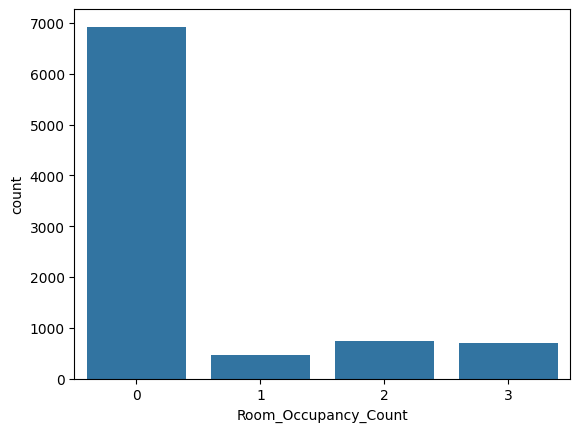

In [67]:
#room occ count  balanced or imbalanced 
sns.countplot(x=df1['Room_Occupancy_Count'])

Temperature sensors show minor variation, suggesting that temperature alone may not strongly determine room occupancy.

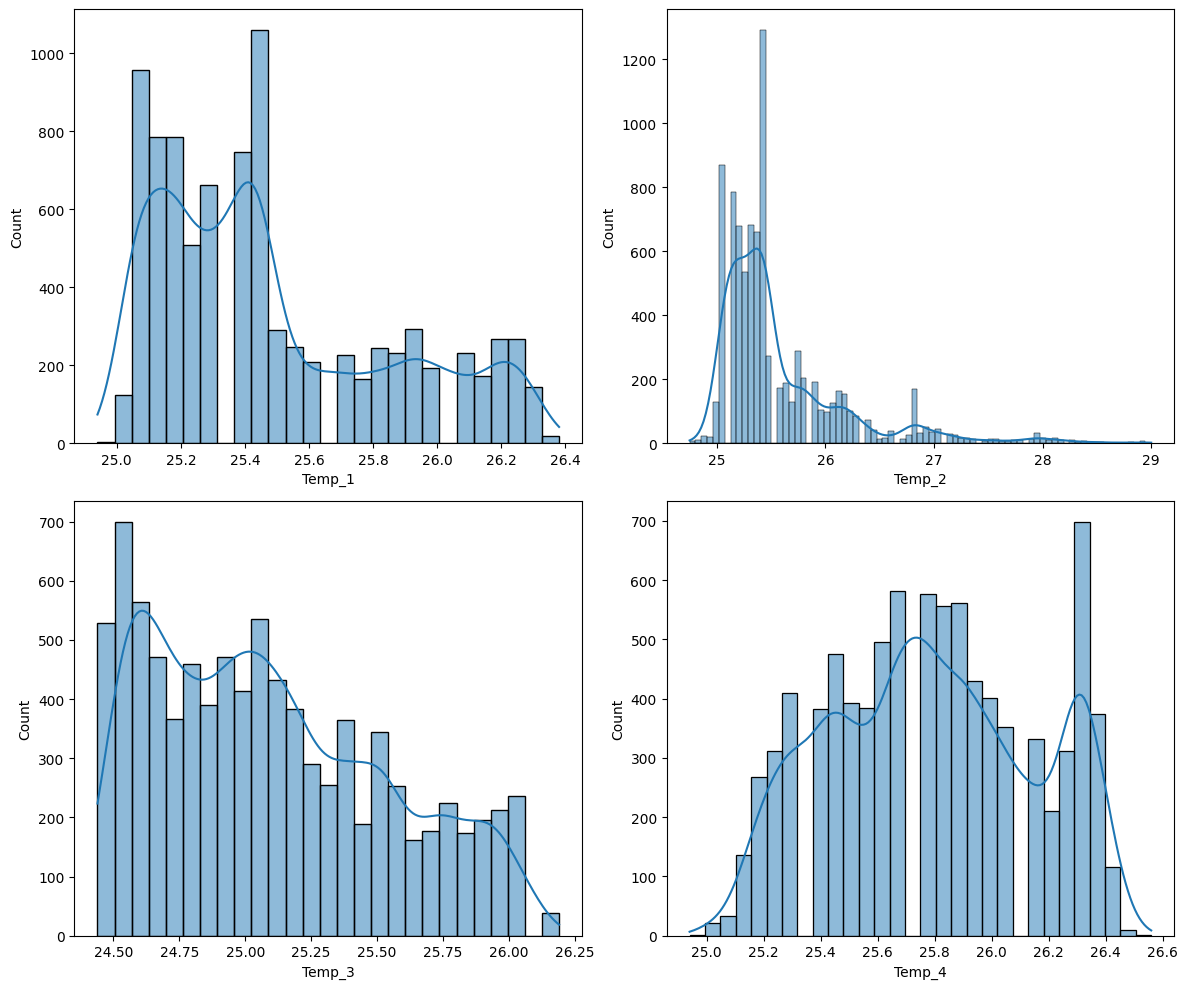

In [68]:
col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].startswith('Temp')]

plt.figure(figsize=(12,10))

for index, column in enumerate(col):
    plt.subplot(2, 2, index+1)
    sns.histplot(df1[column], kde=True)

plt.tight_layout()


Sound sensors exhibit sparse spikes indicating activity. They may contribute to occupancy detection but are less stable compared to CO₂.

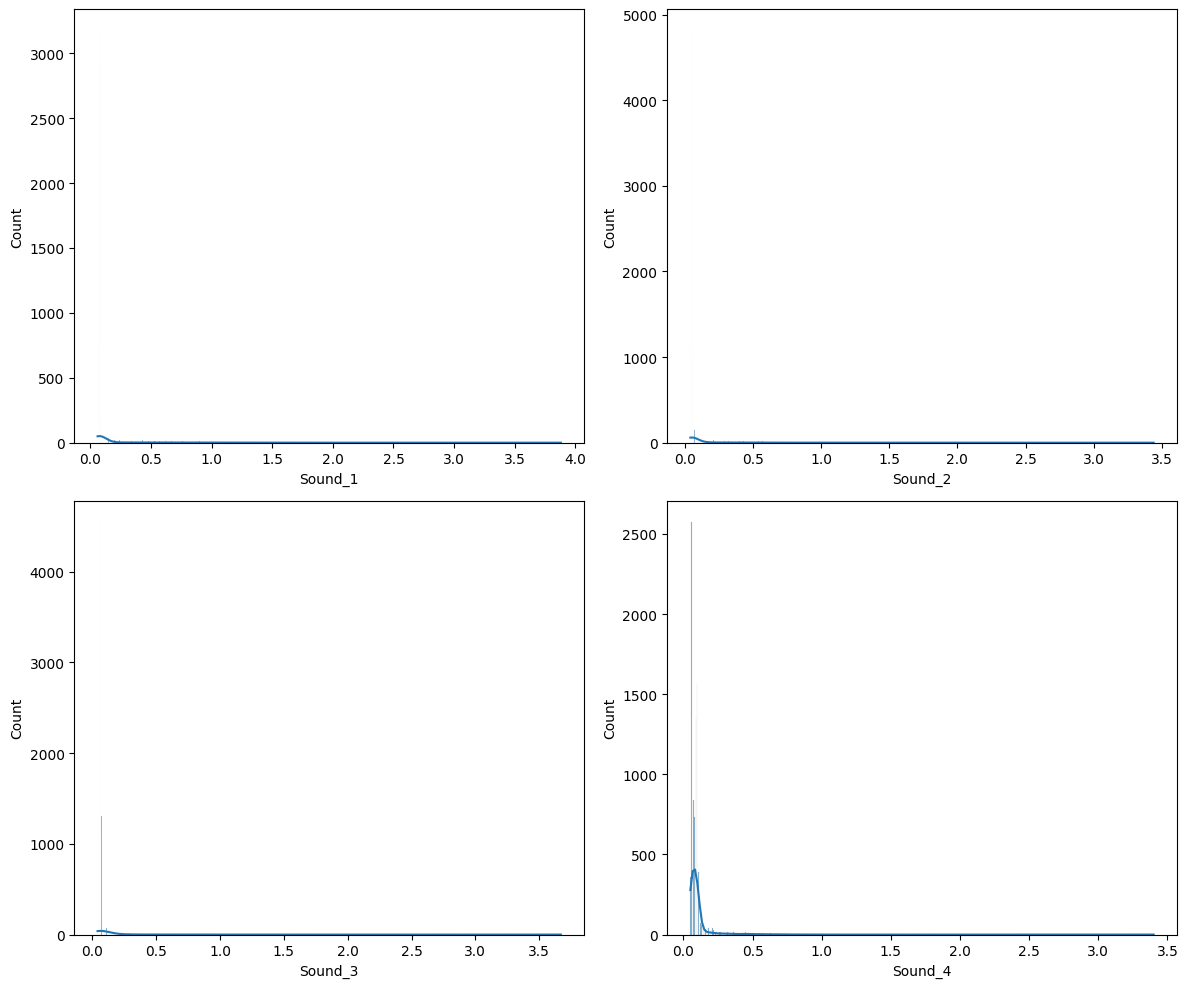

In [69]:
col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].startswith('Sound')]

plt.figure(figsize=(12,10))

for index, column in enumerate(col):
    plt.subplot(2, 2, index+1)
    sns.histplot(df1[column], kde=True)

plt.tight_layout()

they may not consistently indicate occupancy due to dependency on external lighting conditions.

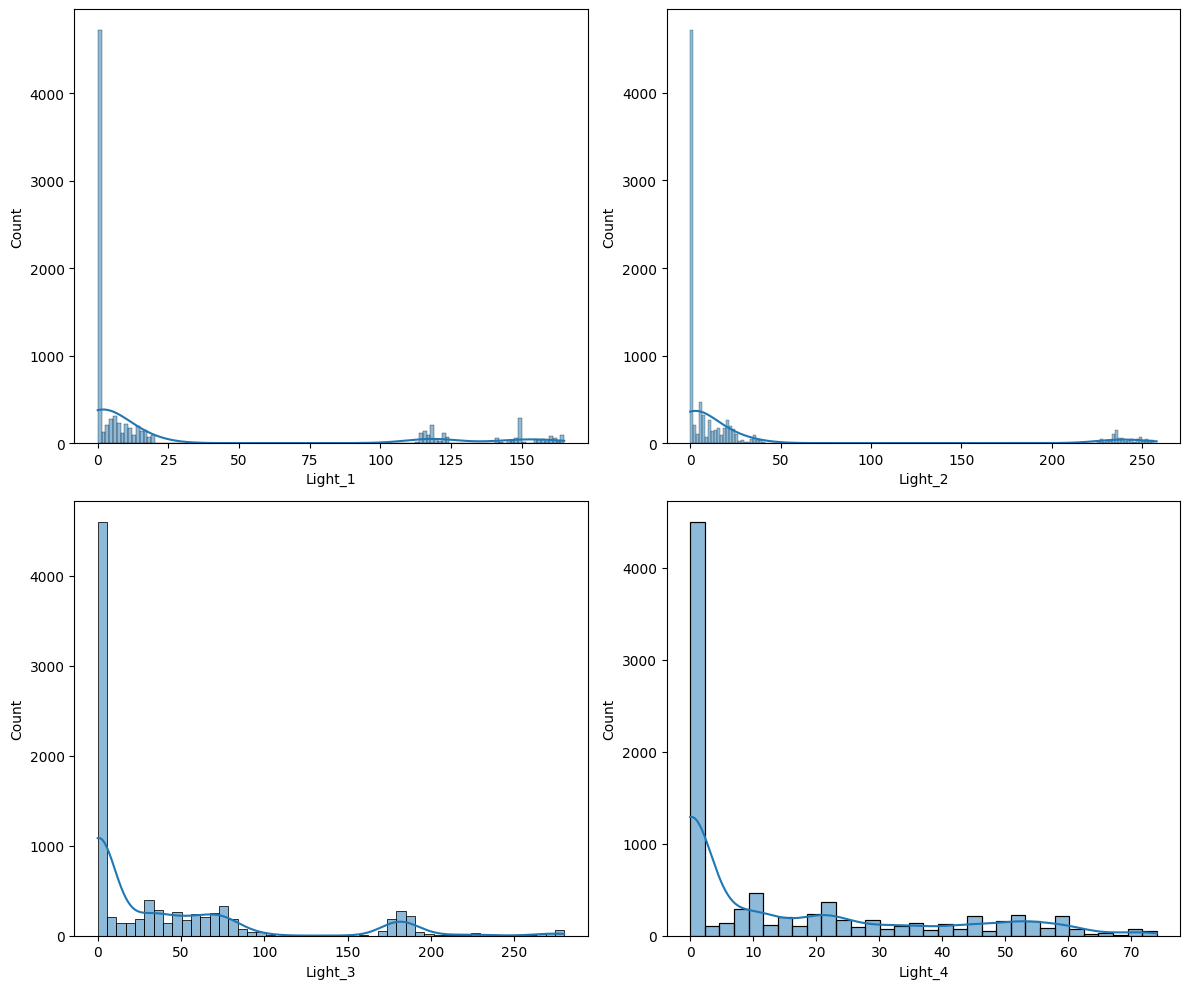

In [70]:
col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].startswith('Light')]

plt.figure(figsize=(12,10))

for index, column in enumerate(col):
    plt.subplot(2, 2, index+1)
    sns.histplot(df1[column], kde=True)

plt.tight_layout()

 Higher CO₂ indicates human presence (breathing) CO₂ levels show strong variation and right-skewed distribution, indicating significant increase during occupied periods, making it a strong predictor of occupancy.

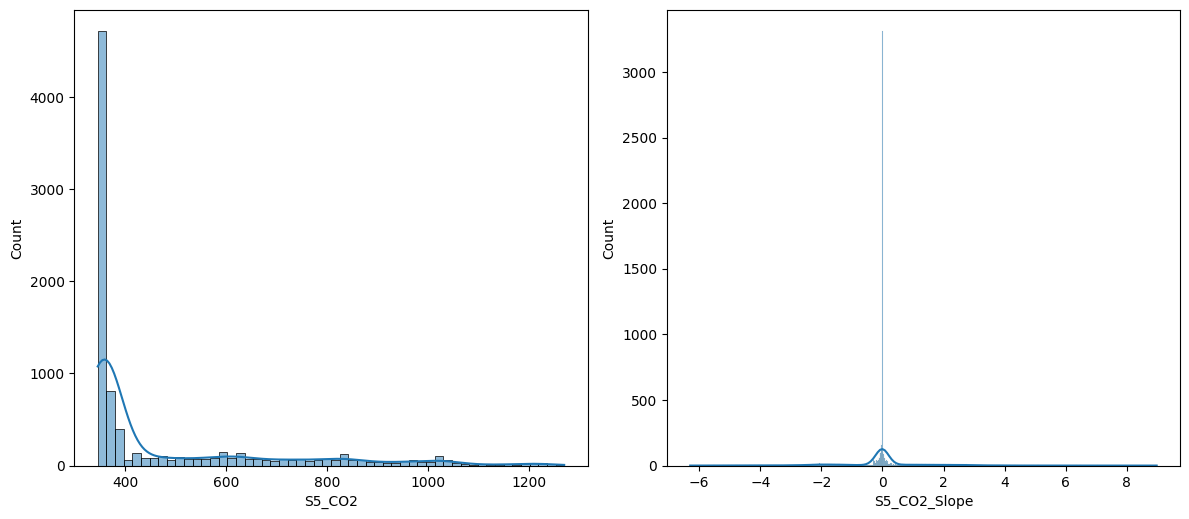

In [71]:
col=[df1.columns[i] for i in range(len(df1.columns)) if df1.columns[i].startswith('S5')]

plt.figure(figsize=(12,10))

for index, column in enumerate(col):
    plt.subplot(2, 2, index+1)
    sns.histplot(df1[column], kde=True)

plt.tight_layout()

Exploratory data analysis revealed that CO₂ concentration shows strong variation and right-skewed distribution, indicating its importance in occupancy detection. Temperature values exhibit minimal variation and limited predictive power. Light and sound sensors display irregular and skewed distributions, contributing moderately to occupancy prediction. Overall, CO₂ and motion-related sensors

<Axes: >

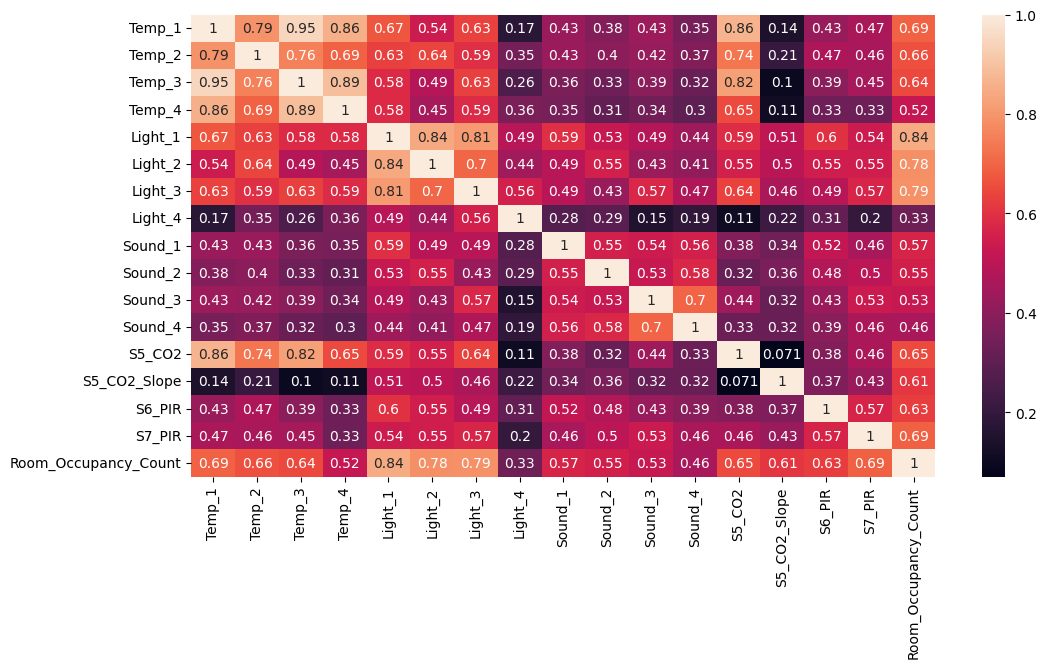

In [72]:
plt.figure(figsize=(12,6))
sns.heatmap(df1.corr(),annot=True)

Correlation analysis reveals that Light sensors show the strongest linear relationship with Room Occupancy Count, followed by Temperature, PIR, and CO₂ sensors. This suggests that lighting conditions in the room change significantly with occupancy.

Although CO₂ shows moderate correlation, ensemble methods like Random Forest can capture nonlinear interactions beyond simple correlation.

In [73]:
x=df1.drop('Room_Occupancy_Count',axis=1)
y=df1['Room_Occupancy_Count']

In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=101)


In [75]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
y_pred=model.predict(x_test)


In [77]:
print('\n the accuracy of the model is :',accuracy_score(y_test,y_pred))
print('\n the classification report of the model is :\n',classification_report(y_test,y_pred))
print('\n the confusion matrix of the model is :\n',confusion_matrix(y_test,y_pred))



 the accuracy of the model is : 0.9971687429218573

 the classification report of the model is :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1395
           1       1.00      0.99      0.99        89
           2       0.99      0.98      0.99       146
           3       0.97      1.00      0.99       136

    accuracy                           1.00      1766
   macro avg       0.99      0.99      0.99      1766
weighted avg       1.00      1.00      1.00      1766


 the confusion matrix of the model is :
 [[1394    0    0    1]
 [   0   88    1    0]
 [   0    0  143    3]
 [   0    0    0  136]]


The Random Forest model achieved an accuracy of 99.88% on the test dataset. The confusion matrix indicates minimal misclassification across all occupancy levels. The model demonstrates strong predictive capability for both majority and minority classes.

Since data is  in sequential form  and we do the random split there must be possibilities of data leakage so we split it sequentialy

In [80]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [126]:
df2=df.copy()

In [127]:
df2['date_time']=df['Date']+' '+df['Time']

In [128]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [129]:
df2['date_time']=pd.to_datetime(df2['date_time'])

In [130]:
df2=df2.drop(['Date','Time'],axis=1)

In [131]:
df2.drop_duplicates(inplace=True)

In [132]:
df2.head()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,date_time
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,2017-12-22 10:50:42
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,2017-12-22 10:51:13
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,2017-12-22 10:51:44


In [133]:
df2.shape

(10129, 18)

In [134]:
df2=df2.sort_values(by='date_time')

In [135]:
df2.head()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,date_time
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,2017-12-22 10:50:42
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,2017-12-22 10:51:13
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,2017-12-22 10:51:44


In [136]:
index=int(0.8*len(df2))
train=df2.iloc[:index]
test=df2.iloc[index:]

In [137]:
train.columns

Index(['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light',
       'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound',
       'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count',
       'date_time'],
      dtype='object')

In [140]:
train_x=train.drop(['Room_Occupancy_Count','date_time'],axis=1)
train_y=train['Room_Occupancy_Count']
test_x=test.drop(['Room_Occupancy_Count','date_time'],axis=1)
test_y=test['Room_Occupancy_Count']

In [141]:
model1=RandomForestClassifier()
model1.fit(train_x,train_y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
y_pred1=model1.predict(test_x)
print('\n the accuracy of the model is :',accuracy_score(test_y,y_pred1))
print('\n the classification report of the model is :\n',classification_report(test_y,y_pred1))
print('\n the confusion matrix of the model is :\n',confusion_matrix(test_y,y_pred1))


 the accuracy of the model is : 0.9264560710760118

 the classification report of the model is :
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      1751
           2       0.95      0.38      0.54        93
           3       0.61      0.50      0.55       182

    accuracy                           0.93      2026
   macro avg       0.84      0.63      0.69      2026
weighted avg       0.92      0.93      0.92      2026


 the confusion matrix of the model is :
 [[1751    0    0]
 [   0   35   58]
 [  89    2   91]]


After applying time-based splitting, model accuracy reduced to 92.64%, indicating more realistic generalization. The model performs strongly for the majority class (Unoccupied), but shows difficulty distinguishing between occupancy levels 2 and 3 due to overlapping sensor behavior.

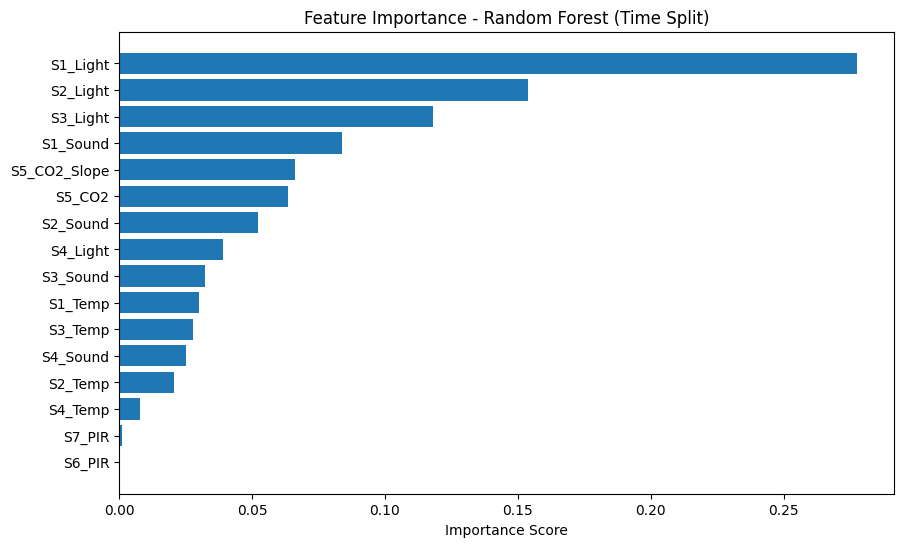

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model1.feature_importances_


feat_importance = pd.DataFrame({
    'Feature': train_x.columns,
    'Importance': importances
})

feat_importance = feat_importance.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feat_importance['Feature'],feat_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest (Time Split)")
plt.xlabel("Importance Score")
plt.show()


Feature importance analysis reveals that light sensors (S1_Light, S2_Light, S3_Light) are the most influential predictors of room occupancy. This suggests that lighting conditions strongly correlate with occupancy patterns in the dataset. CO₂ slope shows higher importance than raw CO₂ levels, indicating that sudden changes in CO₂ concentration are more predictive than absolute values. Temperature and PIR sensors contribute minimally, suggesting limited variability in these signals relative to occupancy changes

In [146]:
feat_importance

,Feature,Importance
4,S1_Light,0.277700
5,S2_Light,0.153778
6,S3_Light,0.118115
8,S1_Sound,0.083724
13,S5_CO2_Slope,0.066091
12,S5_CO2,0.063456
9,S2_Sound,0.052384
7,S4_Light,0.039212
10,S3_Sound,0.032342
0,S1_Temp,0.030052


In [155]:
gird_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
    
}
gridsearch=GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=gird_params, cv=5,n_jobs=-1, verbose=2,scoring='f1_weighted')
gridsearch.fit(train_x,train_y)
y_pred_grid=gridsearch.predict(test_x)
print('Best Hyperparameters:', gridsearch.best_params_)
print('\n the accuracy of the model is :',accuracy_score(test_y,y_pred_grid))
print('\n the classification report of the model is :\n',classification_report(test_y,y_pred_grid))
print('\n the confusion matrix of the model is :\n',confusion_matrix(test_y ,y_pred_grid))


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

 the accuracy of the model is : 0.9249753208292202

 the classification report of the model is :
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1751
           2       0.95      0.41      0.57        93
           3       0.61      0.47      0.53       182

    accuracy                           0.92      2026
   macro avg       0.84      0.63      0.69      2026
weighted avg       0.92      0.92      0.92      2026


 the confusion matrix of the model is :
 [[1751    0    0]
 [   0   38   55]
 [  95    2   85]]


In [157]:
random_params = {
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
    
}
random=RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=random_params, cv=5,n_jobs=-1, verbose=2,scoring='f1_weighted')
random.fit(train_x,train_y)
y_pred_random=random.predict(test_x)
print('Best Hyperparameters:', random.best_params_)
print('\n the accuracy of the model is :',accuracy_score(test_y,y_pred_random))
print('\n the classification report of the model is :\n',classification_report(test_y,y_pred_random))
print('\n the confusion matrix of the model is :\n',confusion_matrix(test_y ,y_pred_random))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'gini'}

 the accuracy of the model is : 0.9239881539980257

 the classification report of the model is :
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1751
           2       0.95      0.41      0.57        93
           3       0.60      0.46      0.52       182

    accuracy                           0.92      2026
   macro avg       0.83      0.62      0.69      2026
weighted avg       0.92      0.92      0.91      2026


 the confusion matrix of the model is :
 [[1751    0    0]
 [   0   38   55]
 [  97    2   83]]


Hyperparameter tuning using RandomizedSearchCV resulted in minimal performance improvement. This indicates that the baseline Random Forest model was already well-configured. The primary challenge lies in distinguishing between occupancy levels 2 and 3 due to overlapping environmental patterns rather than model complexity.

In [165]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_y_enc = le.fit_transform(train_y)
test_y_enc = le.transform(test_y)


In [166]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(train_x, train_y_enc)

y_pred_xgb = xgb.predict(test_x)


In [167]:
print("Accuracy:", accuracy_score(test_y_enc, y_pred_xgb))
print(classification_report(test_y_enc, y_pred_xgb))
print(confusion_matrix(test_y_enc, y_pred_xgb))


Accuracy: 0.9106614017769002
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1751
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        93
           3       0.58      0.52      0.55       182

    accuracy                           0.91      2026
   macro avg       0.38      0.38      0.38      2026
weighted avg       0.88      0.91      0.89      2026

[[1750    0    0    1]
 [   0    0    0    0]
 [   0   25    0   68]
 [  86    1    0   95]]


The Random Forest model with time-based splitting provides the most reliable and realistic performance (~92.6% accuracy).

The model performs exceptionally well in detecting unoccupied states but faces difficulty distinguishing between occupancy levels 2 and 3 due to overlapping environmental patterns.

Hyperparameter tuning and alternative algorithms (XGBoost) did not significantly improve performance, indicating that dataset characteristics are the primary limiting factor.